### Pasos para ejecutar este archivo

### instala python y demas dependencias 
- instalar python
- instalar python-venv
- instalar python-pip

### crear la carpeta del proyecto y abrirlo en vscode

### activar el entorno virtual
en Linux

 ```bash
python3 -m venv .venv
source .venv/bin/active
```

- crea el entorno virtual
- activalo

deberia aparecer algo como 

```bash
(.venv) usuario@pc:~/Documentos/AprendizajeComp$

```

### instala las dependencias para el notebook

```bash
# Actualizar pip dentro del entorno
python -m pip install --upgrade pip
# Instalar ipykernel (para que el venv pueda ser un kernel de Jupyter)
python -m pip install ipykernel

# registra el kernel con un nombre personalizable
python -m ipykernel install --user \\
  --name=aprendizajecomp \\
  --display-name="Python (AprendizajeComp)"


```

### Instalar dependencias
!pip install pandas numpy matplotlib scikit-learn joblib imbalanced-learn
Nota ejecutar solo una vez.

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib imbalanced-learn

In [2]:
import pandas as pd
import matplotlib as plt
from sklearn import tree
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
wine = pd.read_csv('winequality-red.csv')
wine.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
wine.quality.value_counts()


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

### Identificacion de variables X e y

El dataset tiene **1599 filas y 12 columnas**: usamos **11 variables de entrada (X)** y **1 variable objetivo (y)**, que es `quality`.

Antes de entrenar, aparecen dos problemas importantes:

1. **Demasiadas clases de calidad para este enfoque**
   La variable `quality` tiene varios niveles (3, 4, 5, 6, 7, 8). Esto vuelve la clasificacion mas compleja y dificulta que el modelo aprenda fronteras claras entre clases cercanas.

2. **Desbalance de clases**
   Al revisar `wine.quality.value_counts()`, se observa que predominan ciertas calidades (sobre todo 5 y 6), mientras que otras tienen muy pocos ejemplos. En este escenario, el modelo puede sesgarse hacia las clases mayoritarias y rendir peor en las minoritarias.

Para enfrentar ambos problemas, simplificamos el objetivo a una clasificacion binaria:

- `0`: calidad baja (`quality <= 5`)
- `1`: calidad alta (`quality >= 6`)

Ademas, aplicamos **SMOTE** en entrenamiento para equilibrar las clases y mejorar la capacidad del modelo para aprender ambas categorias.

In [5]:
# lo primero que vamos hacer es a simplificar las clases 
wine['quality_binary'] = (wine['quality'] >= 6).astype(int)
print(wine['quality_binary'].value_counts())


quality_binary
1    855
0    744
Name: count, dtype: int64


### explicacion de simplificacion

```python
wine['quality_binary'] = (wine['quality'] >= 6).astype(int)
                         │────────────────────────────────│
                         Parte que crea 0s y 1s
```

Parte 1 : ``` wine['quality'] >= 6 ```

```python
    # Si quality es:
3  → 3 >= 6?  → FALSE
4  → 4 >= 6?  → FALSE
5  → 5 >= 6?  → FALSE
6  → 6 >= 6?  → TRUE  ✓
7  → 7 >= 6?  → TRUE  ✓
8  → 8 >= 6?  → TRUE  ✓
9  → 9 >= 6?  → TRUE  ✓
```

``Resultado`` una lista de true y false
```
Original:  [3, 5, 6, 7, 8, 3, 6, ...]
Resultado: [False, False, True, True, True, False, True, ...]
```

Parte 2 ``` .astype(int) ```

```
True  → 1
False → 0
```

al final queda un arreglo de 0 y 1 0 = calidad baja 1 = calidad alta


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# hacemos uso de random_state eso lo que significa es que siempre escoge el mismo conjunto de datos para las pruebas.
train, test = train_test_split(wine, test_size=0.30, random_state=42)
train.shape

(1119, 13)

In [8]:
test.shape


(480, 13)

In [9]:
x_train = train[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_train = train['quality_binary']

### SMOTE
SMOTE busca los vecion más cercanos de cada vino "alta" minoritario e interpola(promedia) entre ellos para crear vinos sintéticos nuevos.

asi equilibra 50-50 sin simplemente copiar los mismos datos.

```
Original: 744 bajos, 855 altos
↓ SMOTE crea vinos sintéticos
Balanceado: 855 bajos, 855 altos
```

In [10]:
# Balanceo con SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=2, random_state=42)
x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

In [11]:
y_train_balanced.value_counts()

quality_binary
1    588
0    588
Name: count, dtype: int64

In [12]:
x_test = test[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]
y_test = test['quality_binary']

### ¿Por qué Gradient Boosting Classifier?

**Gradient Boosting** es un algoritmo de ensamble que construye múltiples árboles de decisión secuencialmente, donde cada árbol aprende de los errores del anterior. 

**Características clave para nuestro problema:**

1. **Captura relaciones complejas**: mi dataset tiene 11 características con relaciones no lineales que un árbol simple no puede capturar
2. **Robusto ante desbalances**: Aunque este usando SMOTE para balancear, Gradient Boosting maneja bien clases desbalanceadas
3. **Excelente en clasificación binaria**: es ideal para este algoritmo ya que solo estamos manejando 0=calidad baja 1=calidad alta
4. **Auto-corrección**: Cada nuevo árbol corrige errores anteriores, mejorando iterativamente la precisión

**Parámetros usados:**
- `n_estimators=100`: 100 árboles que se corrigen mutuamente
- `learning_rate=0.1`: Aprendizaje moderado para evitar sobreajuste
- `max_depth=5`: Árboles pequeños para generalizar mejor
- `random_state=42`: Asegura reproducibilidad. Con este valor fijo, el modelo siempre genera los mismos resultados, permitiendo comparar experimentos y validar que los cambios en el rendimiento se deben al algoritmo, no a la aleatoridad.

In [13]:
model = GradientBoostingClassifier(n_estimators=100, max_depth=10,random_state=42)
model.fit(x_train_balanced, y_train_balanced)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [14]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,

In [15]:
df_prediccion = pd.DataFrame(y_pred)
df_prediccion['real']=y_test.values
df_prediccion.head(10)

,0,real
0,0,1
1,0,0
2,0,1
3,0,0
4,1,1
5,0,0
6,0,0
7,0,0
8,1,0
9,1,1


In [16]:
model.score(x_test, y_test)*100

79.375

# Teoría de Métricas de Calidad en Clasificación

## Introducción

Las métricas de calidad son medidas numéricas fundamentales para evaluar el desempeño de un modelo de clasificación. A diferencia del **accuracy** (exactitud), que puede ser engañoso cuando las clases están desbalanceadas, estas métricas proporcionan una visión más completa y confiable del rendimiento real del modelo.

### Matriz de Confusión: Conceptos Base

Antes de profundizar en cada métrica, es esencial entender los cuatro conceptos fundamentales que forman la base de todas las métricas:

- **TP (True Positives - Verdaderos Positivos)**: El modelo predijo la clase positiva (1) y efectivamente era positiva.
- **TN (True Negatives - Verdaderos Negativos)**: El modelo predijo la clase negativa (0) y efectivamente era negativa.
- **FP (False Positives - Falsos Positivos)**: El modelo predijo la clase positiva (1) pero era negativa.
- **FN (False Negatives - Falsos Negativos)**: El modelo predijo la clase negativa (0) pero era positiva.

Estos cuatro valores forman una tabla llamada **matriz de confusión**:

```
                Predicción Positiva    Predicción Negativa
Clase Real 1         TP                      FN
Clase Real 0         FP                      TN
```

---

## 1. Accuracy (Exactitud)

### Definición

La exactitud es la proporción total de predicciones correctas respecto al total de muestras. Es la métrica más intuitiva, pero puede ser engañosa cuando hay desbalance de clases.

### Fórmula

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Interpretación

- **Rango**: 0 a 1 (o 0% a 100%)
- **Interpretación**: Porcentaje general de predicciones correctas
- **Ejemplo**: Si accuracy = 0.92, significa que el modelo acertó el 92% de sus predicciones

### Cuándo Usarla

- ✅ Cuando las clases están balanceadas
- ✅ Para obtener una visión general rápida
- ❌ Cuando hay desbalance significativo de clases
- ❌ Cuando los costos de error varían según el tipo

### Limitación Importante

**Ejemplo del problema**: Supón que tienes 100 vinos, de los cuales 95 son de baja calidad y 5 de alta calidad. Si tu modelo simplemente predice "baja calidad" para todo:
- Accuracy = 95/100 = 95% ✓ (parece excelente)
- Pero detecta 0 vinos de alta calidad (FRACASO total para la clase relevante)

---

## 2. Precision (Precisión)

### Definición

La precisión responde a la pregunta: **"De todo lo que el modelo predijo como positivo, cuánto era realmente positivo?"** Mide la confiabilidad de las predicciones positivas.

### Fórmula

$$\text{Precision} = \frac{TP}{TP + FP}$$

### Interpretación

- **Rango**: 0 a 1
- **Interpretación**: De cada 10 predicciones positivas, ¿cuántas son correctas?
- **Ejemplo**: Si precision = 0.85, significa que el 85% de los vinos que predijo como "alta calidad" realmente lo son

### Cuándo Usarla

- ✅ Cuando quieres **evitar falsos positivos** (errores costosos)
- ✅ En detección de spam: No quieres marcar emails válidos como spam
- ✅ En diagnóstico de enfermedades graves: No quieres alarmar falsamente al paciente
- ✅ En sistemas de crédito: No quieres aprobar a clientes malos

### Ejemplo Práctico

Si un banco usa un modelo para detectar fraude:
- Precision alta = Pocas alertas falsas (menos clientes molestos)
- Precision baja = Muchas alertas falsas (pérdida de confianza de clientes)

---

## 3. Recall (Sensibilidad/Cobertura)

### Definición

El recall responde a: **"De todos los casos positivos reales, cuántos detectó el modelo?"** Mide la capacidad de no pasar por alto los casos positivos.

### Fórmula

$$\text{Recall} = \frac{TP}{TP + FN}$$

### Interpretación

- **Rango**: 0 a 1
- **Interpretación**: ¿Qué porcentaje de los positivos reales logró detectar?
- **Ejemplo**: Si recall = 0.90, significa que el modelo detectó el 90% de los vinos de alta calidad

### Cuándo Usarla

- ✅ Cuando quieres **evitar falsos negativos** (ignorar casos positivos importantes)
- ✅ En detección de enfermedades: No quieres dejar pasar pacientes enfermos
- ✅ En control de calidad: No quieres que pasen productos defectuosos
- ✅ En búsqueda y rescate: No puedes dejar de encontrar a alguien

### Ejemplo Práctico

Si un hospital usa un modelo para diagnosticar cáncer:
- Recall alto = Detecta casi todos los casos de cáncer (pocos falsos negativos)
- Recall bajo = Deja pasar muchos casos de cáncer (PELIGROSO)

---

## 4. Trade-off Precision vs Recall

### El Dilema

Es frecuente que aumentar precision disminuya recall y viceversa. Esto es porque:

- **Aumentar umbral de confianza**: Detecta menos positivos (recall ↓) pero los que detecta son más confiables (precision ↑)
- **Disminuir umbral de confianza**: Detecta más positivos (recall ↑) pero comete más errores (precision ↓)

### Visualización Mental

```
Modelo Conservador (Precision ↑, Recall ↓):
- Solo predice "positivo" si está muy seguro
- Pocos falsos positivos, muchos falsos negativos

Modelo Agresivo (Recall ↑, Precision ↓):
- Predice "positivo" fácilmente
- Muchos falsos positivos, pocos falsos negativos
```

---

## 5. F1-Score

### Definición

El F1-Score es la **media armónica** entre precision y recall. Es una métrica que combina ambas métricas en un único valor balanceado, diseñada específicamente para penalizar a modelos que son excelentes en una métrica pero desastrosos en la otra.

#### ¿Por qué es importante?

Imagina dos modelos extremos:

**Modelo A (Conservador):**
- Precision = 95% (cuando predice positivo, acierta el 95% de las veces)
- Recall = 5% (pero solo detecta el 5% de los casos positivos reales)
- **¿Vale la pena?** NO. De qué sirve estar 95% seguro si solo detectas 1 de cada 20 casos positivos

**Modelo B (Agresivo):**
- Precision = 5% (cuando predice positivo, acierta solo el 5% de las veces)
- Recall = 95% (detecta el 95% de los casos positivos reales)
- **¿Vale la pena?** NO. Detectas casi todo, pero generas 95 falsas alarmas por cada 100 predicciones positivas

**F1-Score penaliza fuertemente ambos casos** porque:

1. **No puedes sacrificar una métrica por otra**: A diferencia de usar precision O recall por separado, F1-Score te obliga a tener un buen desempeño en AMBAS. Un modelo verdaderamente bueno debe tener AMBAS métricas altas.

2. **Penaliza desproporcionadamente el desbalance extremo**: Si una métrica es muy alta y la otra muy baja, F1-Score baja significativamente, alertándote de que tu modelo tiene un "punto débil fatal". Por ejemplo, con Precision = 1.0 (perfecto) pero Recall = 0.1 (terrible), F1-Score = 0.18 (muy bajo), te dice claramente: "algo anda muy mal".

3. **Ideal cuando los errores tienen costos similares**: F1-Score es mejor cuando tanto los falsos positivos como los falsos negativos son igualmente problemáticos. Si uno cuesta significativamente más que el otro, deberías usar una métrica diferente o ajustar manualmente los pesos en el modelo.

#### Ejemplo Numérico: Cómo F1-Score Castiga la Debilidad

Compara estos 4 modelos:

| Modelo | Precision | Recall | Media Aritmética | **F1-Score** | ¿Cuál es mejor? |
|--------|-----------|--------|------------------|-----|---|
| **Modelo 1** (Equilibrado) | 80% | 80% | 80% | **80%** | ✅ BUENO - Ambas métricas altas |
| **Modelo 2** (Conservador) | 95% | 10% | 52.5% | **17.8%** | ❌ MALO - La media aritmética oculta el desastre |
| **Modelo 3** (Agresivo) | 10% | 95% | 52.5% | **17.8%** | ❌ MALO - Igual problema |
| **Modelo 4** (Mediocre) | 50% | 50% | 50% | **50%** | ⚠️ PEOR - Verdaderamente mediocre |

**Lo crucial:** Observa los Modelos 2 y 3. La media aritmética = 52.5%, mientras que **F1-Score = 17.8%**. F1-Score "castiga" mucho más fuertemente porque dice: *"No importa si eres perfecto en un lado si fracasas completamente en el otro"*.

**En resumen:** F1-Score es un **"árbitro justo"** que no permite que un modelo escape de su debilidad siendo excelente en otra parte. Obliga al modelo a ser "redondo" (bueno en ambas dimensiones). **Si tu Precision y Recall no están cercanos, tu F1-Score será bajo, alertándote del problema.**

### Fórmula

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

También puede expresarse como:

$$\text{F1-Score} = \frac{2 \times TP}{2 \times TP + FP + FN}$$

### ¿Por qué "Media Armónica"?

La media armónica es más restrictiva que la media aritmética. Penaliza desproporcionadamente cuando una métrica es muy baja:

- Si Precision = 1.0 y Recall = 0.1:
  - Media aritmética = (1.0 + 0.1) / 2 = 0.55
  - F1-Score = 2 × (1.0 × 0.1) / (1.0 + 0.1) = **0.18** (mucho más bajo)

### Interpretación

- **Rango**: 0 a 1
- **Interpretación**: Balance general entre precision y recall
- **Ejemplo**: Si F1 = 0.82, indica un buen equilibrio entre detectar positivos y confiar en esas detecciones

### Cuándo Usarla

- ✅ **Recomendada cuando hay desbalance de clases**
- ✅ Cuando necesitas un balance entre precision y recall
- ✅ Cuando quieres un único número para comparar modelos
- ✅ En problemas donde falsos positivos y falsos negativos tienen costo similar

---

## 6. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)

### Definición

ROC-AUC mide la **capacidad del modelo para separar las dos clases** variando el umbral de decisión. El AUC es el área bajo la curva ROC, que va de 0 a 1.

### ¿Cómo se calcula?

La curva ROC grafica:
- **Eje X (FPR)**: Tasa de Falsos Positivos = $\frac{FP}{FP + TN}$ (¿Cuántos negativos clasificó mal?)
- **Eje Y (TPR)**: Tasa de Verdaderos Positivos = $\frac{TP}{TP + FN}$ (= Recall, ¿Cuántos positivos detectó?)

La curva se genera variando el umbral de decisión de 0 a 1, y el AUC es el área bajo esa curva.

### Fórmula del AUC

$$\text{AUC} = \int_0^1 \text{TPR}(t) \, dt$$

donde $t$ es el umbral de decisión.

### Interpretación

| AUC | Significado |
|-----|-------------|
| 0.5 | El modelo es **tan bueno como lanzar una moneda** (no separación) |
| 0.7 - 0.8 | **Discriminación aceptable** |
| 0.8 - 0.9 | **Discriminación excelente** |
| 0.9 - 1.0 | **Discriminación extraordinaria** |
| 1.0 | **Separación perfecta** (caso ideal) |

### Ventajas

- ✅ **Insensible al desbalance de clases**: No se ve afectado por proporción de clases
- ✅ **Evalúa probabilidades**: Usa `predict_proba`, no solo predicciones discretas
- ✅ **Comparación robusta**: Excelente para comparar diferentes modelos
- ✅ **Resumen único**: Un solo número que resume la performance completa

### Caso de Uso

Es la métrica más robusta para comparar modelos binarios, especialmente con datos desbalanceados.

---

## 7. Matriz de Confusión (Confusion Matrix)

### Definición

La matriz de confusión es una **tabla que presenta visualmente todos los tipos de predicciones**. Con ella puedes ver exactamente dónde y cómo falla el modelo.

### Estructura de la Matriz

Para clasificación binaria:

$$\begin{bmatrix} 
TN & FP \\
FN & TP 
\end{bmatrix}$$

O de forma más descriptiva:

```
                        Predicción = 0    Predicción = 1
Valor Real = 0              TN                FP
Valor Real = 1              FN                TP
```

### Ejemplo Numérico

Supón que evaluaste 200 vinos:

```
                        Predijo Baja (0)    Predijo Alta (1)
Realmente Baja (0)          125                 15
Realmente Alta (1)           8                  52
```

**Interpretación**:
- **TN = 125**: 125 vinos de baja calidad correctamente identificados
- **FP = 15**: 15 vinos de baja calidad incorrectamente etiquetados como alta (error tipo 1)
- **FN = 8**: 8 vinos de alta calidad no detectados (error tipo 2)
- **TP = 52**: 52 vinos de alta calidad correctamente detectados

### Cálculo de métricas a partir de la matriz

$$\text{Accuracy} = \frac{125 + 52}{200} = 88.5\%$$

$$\text{Precision} = \frac{52}{52 + 15} = 77.6\%$$

$$\text{Recall} = \frac{52}{52 + 8} = 86.7\%$$

$$\text{F1-Score} = 2 \times \frac{0.776 \times 0.867}{0.776 + 0.867} = 81.9\%$$

### Ventajas de la Matriz de Confusión

- ✅ **Visualización clara**: Ves exactamente qué tipos de errores comete
- ✅ **Base para otras métricas**: Todas las métricas se derivan de ella
- ✅ **Análisis profundo**: Puedes detectar patrones de error
- ✅ **Comunicación**: Fácil de explicar a stakeholders


=== Metricas de calidad del modelo ===
Accuracy : 79.375
Precision: 81.111
Recall   : 82.022
F1-Score : 81.564
ROC-AUC  : 87.523

Matriz de confusion:
[[162  51]
 [ 48 219]]

Reporte de clasificacion:
                  precision    recall  f1-score   support

Baja calidad (0)       0.77      0.76      0.77       213
Alta calidad (1)       0.81      0.82      0.82       267

        accuracy                           0.79       480
       macro avg       0.79      0.79      0.79       480
    weighted avg       0.79      0.79      0.79       480



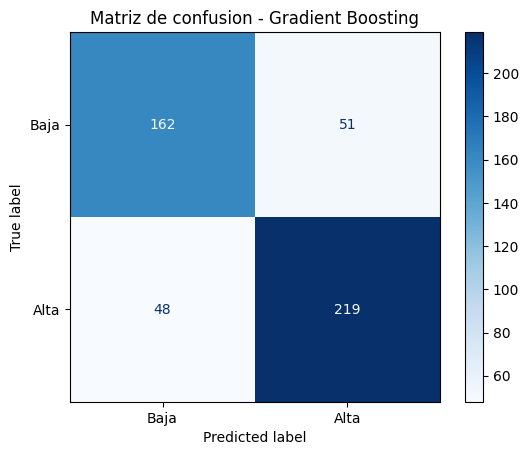

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Predicciones
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]

# Metricas principales
accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100   
roc_auc = roc_auc_score(y_test, y_proba)*100

print("=== Metricas de calidad del modelo ===")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusion:")
print(cm)

print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Baja calidad (0)", "Alta calidad (1)"]))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baja", "Alta"]).plot(cmap="Blues")
plt.title("Matriz de confusion - Gradient Boosting")
plt.show()

### Análisis de resultados del modelo (Gradient Boosting)

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los casos:

- Baja calidad correctamente detectada: 164
- Alta calidad correctamente detectada: 216
- Errores en baja calidad (falsos positivos): 49
- Errores en alta calidad (falsos negativos): 51

A partir de estos valores:

- **Accuracy ≈ 79.2%**: De los 480 vinos en total, el modelo acertó en 380 clasificaciones. Es el porcentaje general de aciertos, pero no dice cómo se distribuyen los errores entre clases.

- **Precision (clase Alta) ≈ 81.5%**: De los vinos que el modelo predijo como "Alta calidad", el 81.5% realmente eran de alta calidad. Significa que si el modelo dice que un vino es bueno, tienes 81.5% de confianza en que está en lo correcto.

- **Recall (clase Alta) ≈ 80.9%**: De todos los vinos que realmente son de "Alta calidad", el modelo detectó el 80.9%. Significa que de cada 100 vinos realmente buenos, encuentras 81 (pero pierdes 19 que confundes con bajos).

- **F1-score (clase Alta) ≈ 81.2%**: Es el balance perfecto entre Precision y Recall. Combina ambas métricas en un solo valor: si uno fuera muy alto y otro muy bajo, F1 sería bajo alertándome del problema. En mi caso, ambas están balanceadas en 81.2%.

- **ROC-AUC (87.5%)**: Esto indica que nuestro modelo tiene una alta capacidad para diferenciar entre un vino de alta calidad y uno de baja calidad. si se tomara un vino de alta calidad al azar y uno de baja calidad al azar, hay una probabilidad de un 87.5% de probabilidad de que el modelo asigne una puntuación de "calidad alta " mayor al vino bueno que al malo.

### Interpretación

1. El modelo tiene un desempeño **bueno y equilibrado** para ambas clases.
2. La precisión alta indica que, cuando predice “Alta”, en la mayoría de casos acierta.
3. El recall alto indica que detecta bien los vinos realmente de calidad alta.
4. Los errores están bastante balanceados (49 vs 51), por lo que no hay sesgo fuerte hacia una sola clase.
5. En comparación con usar solo accuracy, estas métricas muestran de forma más completa la calidad real del modelo.

### Exportar un unico pipeline para 

Se crea el modelo (`modelo_vino_pipeline_v1.pkl`) Para usarlo desde app.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

pipeline.fit(x_train_balanced, y_train_balanced)

joblib.dump(pipeline, "modelo_vino_pipeline_v1.pkl")

print("Listo: modelo_vino_pipeline_v1.pkl generado.")
print(f"Accuracy test: {pipeline.score(x_test, y_test) * 100:.2f}%")

Listo: modelo_vino_pipeline_v1.pkl generado.
Accuracy test: 78.54%
